In [40]:
import importlib
import cisei_lib.planners.planner_classes as pc
importlib.reload(pc)
import cisei_lib.io.geo_service_client as gs
importlib.reload(gs)
import cisei_lib.planners.pole_graph_async as pga
importlib.reload(pga)
import cisei_lib.planners.link_planner as lp
importlib.reload(lp)
import cisei_lib.usermng.home_folder as hf
import cisei_lib.planners.metric_compiler as mc
import cisei_lib.planners.serializer as se
importlib.reload(se)
from cisei_lib.planners.planner_classes import LinkNode

import geopandas as gpd
import pandas as pd
from pathlib import Path
import pandas as pd

df = pd.read_csv('points.csv', index_col=0)
# Convert to dictionary of tuples if needed:
points = {k: tuple(v) for k, v in df.iterrows()}
print(Path.cwd())

/workspaces/network_service/tests/jupyter


In [20]:
client = gs.GeoServiceClient(
    base_url="http://planning-service:8080",
    timeout=20,
)

status = client.workers_status()
print(status.data)

{'hub': {'pid': 379785, 'running': True, 'rss_mb': 56.1796875, 'peak_rss_mb': 56.1796875, 'swap_mb': 0.0}, 'worker_count': 4, 'running_count': 0, 'blocked_count': 0, 'total_worker_rss_mb': 0.0, 'workers': [{'user_id': 'edgard-0', 'status': 'stopped'}, {'user_id': 'edgard-1', 'status': 'stopped'}, {'user_id': 'edgard-2', 'status': 'stopped'}, {'user_id': 'edgard-3', 'status': 'stopped'}]}


In [41]:
if pgo is not None:
    await pgo.close()

pgo = pga.PoleGraph(
    # geo_url="http://10.32.13.19:8080",
    geo_user_prefix="edgard",
    geo_pool_size=2,
)
pgo.context['debug'] = True
await pgo.start()

#user = hf.UserHome('edgard')
#user.create_folders()
#user.check_folders()

#pgo = lp.LinkPlanner('TESTE', user, geo_url='http://192.168.100.29:8080', metric_spec = 'top_peak')

status = client.workers_status()
print(status.data)

APIResult(kind='json')
APIResult(kind='json')
{'hub': {'pid': 390858, 'running': True, 'rss_mb': 60.6796875, 'peak_rss_mb': 60.6796875, 'swap_mb': 0.0}, 'worker_count': 2, 'running_count': 0, 'blocked_count': 0, 'total_worker_rss_mb': 0.0, 'workers': [{'user_id': 'edgard-0', 'status': 'stopped'}, {'user_id': 'edgard-1', 'status': 'stopped'}]}


{'hub': {'pid': 390858, 'running': True, 'rss_mb': 60.6796875, 'peak_rss_mb': 60.6796875, 'swap_mb': 0.0}, 'worker_count': 2, 'running_count': 0, 'blocked_count': 0, 'total_worker_rss_mb': 0.0, 'workers': [{'user_id': 'edgard-0', 'status': 'stopped'}, {'user_id': 'edgard-1', 'status': 'stopped'}]}
{'hub': {'pid': 390858, 'running': True, 'rss_mb': 60.6796875, 'peak_rss_mb': 60.6796875, 'swap_mb': 0.0}, 'worker_count': 2, 'running_count': 1, 'blocked_count': 1, 'total_worker_rss_mb': 2069.2, 'workers': [{'user_id': 'edgard-0', 'status': 'blocked', 'pid': 394379, 'port': 15000, 'active_requests': 0, 'request_count': 3, 'idle_seconds': 0.0, 'soft_limit_mb': 600, 'hard_limit_mb': 8000, 'hard_limit_percent': 25.9, 'running': True, 'rss_mb': 2069.16015625, 'peak_rss_mb': 2163.6484375, 'swap_mb': 0.0}, {'user_id': 'edgard-1', 'status': 'stopped'}]}
{'fspl': 108.95, 'dist_m': 7431.3, 'delta_diffra': 23.63, 'terrain': {'core': 1580, 'fresnel': 1970, 'boundary': 2336.88}, 'vegetation': {'core': 

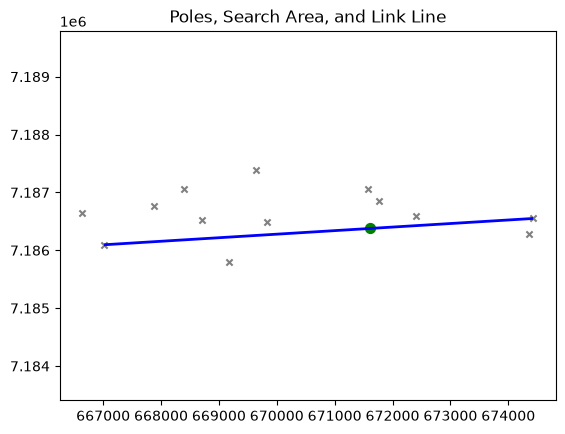

In [42]:
from cisei_lib.planners.planner_classes import Pole
pgo.clear_poles()
pgo.G.clear()
for k,v in points.items():
    pgo.add_pole(
    Pole(
        pole_id=k,
        lat=v[0],
        lon=v[1],
        ant_h=v[2],
    )
)
    
src = 'copel'
dst = 'guaira'

src_node = {'name' : src, 'pos' : points[src][0:2], 'ant_h' : points[src][2]}
dst_node = {'name' : dst, 'pos' : points[dst][0:2], 'ant_h' : points[dst][2]}

status = client.workers_status()
print(status.data)

features = await pgo.edge_metric(
    src_pos=src_node['pos'],
    dst_pos=dst_node['pos'],
    src_ha=src_node['ant_h'],
    dst_ha=src_node['ant_h'],
)

status = client.workers_status()
print(status.data)

print(features)

pgo.add_edge(src_node, dst_node, features)
pgo.show_geometry(src, dst, pgo.poles_utm)

improving: copel guaira


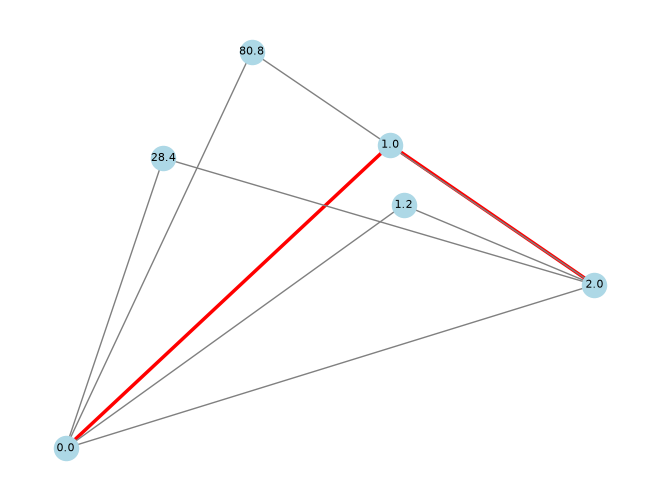

In [43]:
pgo.context['debug'] = True
s_label = src_node['name']
d_label = dst_node['name']
await pgo.graph_expansion(s_label, d_label)
pgo.show_graph(s_label, d_label, show_metric=False)
#pgo.export_geojson_plan()
#pgo.interactive_map()
#await pgo.close()

In [44]:
status = client.workers_status()
print(status.data)
await pgo.close()
status = client.workers_status()
print(status.data)

{'hub': {'pid': 390858, 'running': True, 'rss_mb': 60.6953125, 'peak_rss_mb': 60.6953125, 'swap_mb': 0.0}, 'worker_count': 2, 'running_count': 2, 'blocked_count': 2, 'total_worker_rss_mb': 3181.2, 'workers': [{'user_id': 'edgard-0', 'status': 'blocked', 'pid': 394681, 'port': 15000, 'active_requests': 0, 'request_count': 6, 'idle_seconds': 29.3, 'soft_limit_mb': 600, 'hard_limit_mb': 8000, 'hard_limit_percent': 19.7, 'running': True, 'rss_mb': 1572.484375, 'peak_rss_mb': 2170.33203125, 'swap_mb': 0.0}, {'user_id': 'edgard-1', 'status': 'blocked', 'pid': 394777, 'port': 15001, 'active_requests': 0, 'request_count': 3, 'idle_seconds': 25.4, 'soft_limit_mb': 600, 'hard_limit_mb': 8000, 'hard_limit_percent': 20.1, 'running': True, 'rss_mb': 1608.765625, 'peak_rss_mb': 2205.14453125, 'swap_mb': 0.0}]}
{'hub': {'pid': 390858, 'running': True, 'rss_mb': 60.6953125, 'peak_rss_mb': 60.6953125, 'swap_mb': 0.0}, 'worker_count': 2, 'running_count': 2, 'blocked_count': 2, 'total_worker_rss_mb': 318

In [39]:
print("Cached evaluations:", pgo.geo.cache_size())

for key in pgo.geo._cache:
    tx, rx = key[0], key[1]
    print(tx, "->", rx)

Cached evaluations: 9
(-25.43273083515008, -49.339207159685344) -> (-25.42777449459199, -49.2655361005508)
(-25.423532434217368, -49.29399235240344) -> (-25.42777449459199, -49.2655361005508)
(-25.43273083515008, -49.339207159685344) -> (-25.425356577135183, -49.29212222420152)
(-25.425356577135183, -49.29212222420152) -> (-25.42777449459199, -49.2655361005508)
(-25.43273083515008, -49.339207159685344) -> (-25.42070918830469, -49.31329361366074)
(-25.42070918830469, -49.31329361366074) -> (-25.42777449459199, -49.2655361005508)
(-25.43273083515008, -49.339207159685344) -> (-25.423532434217368, -49.29399235240344)
(-25.423934116093907, -49.32557536250079) -> (-25.42777449459199, -49.2655361005508)
(-25.43273083515008, -49.339207159685344) -> (-25.423934116093907, -49.32557536250079)


In [94]:
from cisei_lib.planners.link_planner import LinkPlanner
from cisei_lib.planners.planner_classes import LinkNode

planner = LinkPlanner(
    project="TESTE",
    user_id="edgard",
    # geo_url="http://192.168.100.29:8080",
    debug=True,
)

await planner.start()

nodes = [
    PlannerNode(
        node_id="copel",
        lat=-25.432730835150082,
        lon=-49.339207159685344,
        ant_h=7,
    ),
    PlannerNode(
        node_id="guaira",
        lat=-25.42777449459199,
        lon=-49.265536100550804,
        ant_h=7,
    ),
    PlannerNode(
        node_id="italia",
        lat=-25.43017531546412,
        lon=-49.266232140399694,
        ant_h=30,
    ),
]

poles = [
    Pole('tenis', -25.425356577135183, -49.29212222420152, ant_h=7),
    Pole('praca_29', -25.427623857466518, -49.28564299624496, ant_h=7),
    Pole('torre', -25.423532434217368, -49.29399235240344, ant_h=100),
    Pole('woodland', -25.42658426446721, -49.33074015773234, ant_h=7),
    Pole('deneka', -25.423934116093907, -49.325575362500786, ant_h=7),
    Pole('cemiterio', -25.42070918830469, -49.31329361366074, ant_h=7),
    Pole('saturno', -25.427866914897244, -49.34300062825045, ant_h=7),
    Pole('decatlon', -25.42866218833271, -49.322405327653435, ant_h=7),
    Pole('shopping', -25.435107506699588, -49.31771087011032, ant_h=7),
    Pole('barigui', -25.428858965702883, -49.31129716330312, ant_h=7),
]

planner.add_nodes(nodes)
planner.add_poles(poles)

await planner.set_link_by_id('copel', 'guaira')
result_1 = await planner.plan_link()

await planner.set_link_by_id('copel', 'italia')
result_2 = await planner.plan_link()


APIResult(kind='json')
APIResult(kind='json')
APIResult(kind='json')
APIResult(kind='json')
worst ('copel', 'guaira') = 28.544999999999998
improving: copel guaira
worst ('copel', 'torre') = 1.0
worst ('tenis', 'guaira') = 5.82
improving: tenis guaira
worst None = -inf
worst ('copel', 'deneka') = 62.4
improving: copel deneka
worst ('copel', 'cemiterio') = 377.28000000000003
improving: copel cemiterio
worst ('copel', 'italia') = 7.680000000000003
improving: copel italia
worst ('copel', 'torre') = 1.0
worst ('copel', 'tenis') = 1.225
worst None = -inf
worst ('copel', 'deneka') = 62.4
improving: copel deneka
worst ('copel', 'cemiterio') = 377.28000000000003
improving: copel cemiterio


In [99]:
await planner.set_link_by_id('guaira', 'italia')
result_2 = await planner.plan_link()

worst ('guaira', 'italia') = 1.0


In [43]:
import multiprocessing as mp
import cisei_lib.planners.link_planner_worker as lpw

importlib.reload(lpw)

from cisei_lib.usermng.home_folder import UserHome
from cisei_lib.planners.planner_classes import PlannerNode, Pole
from cisei_lib.planners.link_planner_worker import LinkPlannerWorker

def run_link_worker(
    username,
    project,
    nodes,
    poles,
    shared_edges,
    shared_nodes,
    queue,
    lock,
    planner_kwargs,
):
    # Construct process-local objects inside the child process.
    home = UserHome(username)

    worker = LinkPlannerWorker(
        project=project,
        home=home,
        shared_edges=shared_edges,
        shared_nodes=shared_nodes,
        queue=queue,
        lock=lock,
        **planner_kwargs,
    )

    # Each worker receives the same immutable input snapshot.
    worker.add_nodes(nodes)
    worker.add_poles(poles)

    worker.consume_links()




In [49]:
import cisei_lib.io.geo_service_pool as gsp
importlib.reload(gsp)
from cisei_lib.io.geo_service_pool import FeatureRequest, AsyncGeoServicePool

requests = [
    FeatureRequest(
        tx=(-25.432730835150082, -49.339207159685344),
        rx=(-25.427774494591990, -49.265536100550804),
        tx_ha=7,
        rx_ha=7,
        tag="A-B",
    ),
    FeatureRequest(
        tx=(-25.432730835150082, -49.339207159685344),
        rx=(-25.430175315464120, -49.266232140399694),
        tx_ha=7,
        rx_ha=30,
        tag="A-C",
    ),
]

pool = AsyncGeoServicePool(
    base_url="http://192.168.100.29:8080",
    pool_size=2,
    timeout=120,
    user_prefix="notebook-test",
)

await pool.start()

if False:
    results = await pool.get_many(requests)
    
    for result in results:
        print(result.request.tag, result.features)


APIResult(kind='json')
APIResult(kind='json')


In [50]:


async for result in pool.as_completed(requests):
    print(
        "Completed:",
        result.request.tag,
        result.features,
    )

await pool.close()

Completed: A-B {'fspl': 108.95, 'dist_m': 7431.3, 'delta_diffra': 23.63, 'terrain': {'core': 1580, 'fresnel': 1970, 'boundary': 2336.88}, 'vegetation': {'core': 0, 'fresnel': 0, 'boundary': 0}, 'buildings': {'core': 2024.76, 'fresnel': 6096.69, 'boundary': 3447.9}, 'terrain_peaks_vv': [{'v_v': 1.73, 'd_norm': 0.62}, {'v_v': 1.22, 'd_norm': 0.17}], 'max_obstruction_angle_rad': 0.01, 'tx_rx_elevation_angle_rad': -0.01, 'tx_near_terminal_clearance_m': 12.73, 'rx_near_terminal_clearance_m': 9.34}
Completed: A-C {'fspl': 108.85, 'dist_m': 7346.36, 'delta_diffra': 18.08, 'terrain': {'core': 340, 'fresnel': 675, 'boundary': 1149.38}, 'vegetation': {'core': 0, 'fresnel': 0, 'boundary': 0}, 'buildings': {'core': 359.81, 'fresnel': 2867.19, 'boundary': 3605.19}, 'terrain_peaks_vv': [{'v_v': 1.34, 'd_norm': 0.64}, {'v_v': 1.01, 'd_norm': 0.18}, {'v_v': 0.49, 'd_norm': 0.48}], 'max_obstruction_angle_rad': 0.0, 'tx_rx_elevation_angle_rad': -0.0, 'tx_near_terminal_clearance_m': 12.89, 'rx_near_termi

In [ ]:
all_shared_edges = dict(shared_edges)
all_shared_nodes = dict(shared_nodes)

global_edges = {
    key: value
    for key, value in all_shared_edges.items()
    if (
        isinstance(key, tuple)
        and len(key) == 2
        and all(isinstance(item, str) for item in key)
    )
}

metric_cache = {
    key: value
    for key, value in all_shared_edges.items()
    if key not in global_edges
}

print("Global evaluated edges:", len(global_edges))
print("Cached metric evaluations:", len(metric_cache))
print("Shared repeater nodes:", len(all_shared_nodes))